In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('df_final_demo_cleaned')
df = df.drop(columns=['Unnamed: 0'])
df = df.drop(columns=['Unnamed: 0.1'])


In [3]:
df

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,169,21,262,47.5,M,2,501570.72,4,4
1,555,3,46,29.5,U,2,25454.66,2,6
2,647,12,151,57.5,M,2,30525.80,0,4
3,722,11,143,59.5,F,2,22466.17,1,1
4,934,9,109,51.0,F,2,32522.88,0,3
...,...,...,...,...,...,...,...,...,...
70590,9999400,7,86,28.5,U,2,51787.04,0,3
70591,9999626,9,113,35.0,M,2,36642.88,6,9
70592,9999729,10,124,31.0,F,3,107059.74,6,9
70593,9999832,23,281,49.0,F,2,431887.61,1,4


In [4]:
df_sorted_1 = df.sort_values(
    by=["bal","clnt_tenure_yr", "clnt_tenure_mnth", "calls_6_mnth", "logons_6_mnth"],
    ascending=[False, True,True, True,True],  
    ).head(int(0.1 * len(df)))
df_sorted_1

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
65646,9286288,21,254,62.5,M,3,16320040.15,6,9
59004,8339240,6,80,26.5,M,2,12838418.01,3,3
49990,7070097,11,133,53.0,M,2,8986419.77,6,9
66709,9440656,7,94,63.0,F,2,8292996.21,6,9
16057,2291985,7,85,41.0,M,2,8247729.97,1,4
...,...,...,...,...,...,...,...,...,...
21242,3032988,10,131,47.5,M,2,319589.21,2,5
47978,6787766,24,294,63.5,U,3,319554.04,6,9
3992,563689,22,269,55.0,M,3,319553.03,2,5
47335,6702347,5,66,65.5,U,2,319497.50,6,9


In [5]:
balance_threshold = df["bal"].quantile(0.90)    

df["primary_client"] = (
    (df["bal"] >= balance_threshold)
)

In [6]:
df

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,primary_client
0,169,21,262,47.5,M,2,501570.72,4,4,True
1,555,3,46,29.5,U,2,25454.66,2,6,False
2,647,12,151,57.5,M,2,30525.80,0,4,False
3,722,11,143,59.5,F,2,22466.17,1,1,False
4,934,9,109,51.0,F,2,32522.88,0,3,False
...,...,...,...,...,...,...,...,...,...,...
70590,9999400,7,86,28.5,U,2,51787.04,0,3,False
70591,9999626,9,113,35.0,M,2,36642.88,6,9,False
70592,9999729,10,124,31.0,F,3,107059.74,6,9,False
70593,9999832,23,281,49.0,F,2,431887.61,1,4,True


In [30]:
df_inc = df[df['clnt_tenure_yr'] > df['clnt_age']]
df_inc

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,primary_client,age_quartile,age_decade,tenure_bin
10,1336,48,576,42.0,M,4,130537.18,6,9,False,Q2,40.0,NaN
173,24002,23,277,19.0,F,2,81457.26,6,6,False,Q1,15.0,20–25
407,55333,30,362,27.5,M,2,50613.02,6,9,False,Q1,25.0,25+
631,85286,25,301,22.0,M,2,25235.17,2,5,False,Q1,20.0,20–25
650,87915,26,315,21.0,F,2,51162.44,3,6,False,Q1,20.0,25+
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69693,9876225,20,242,18.5,M,2,25137.92,7,7,False,Q1,15.0,15–20
69729,9881248,26,313,21.5,M,3,56926.59,2,5,False,Q1,20.0,25+
69759,9885263,26,322,24.0,M,2,126854.49,7,7,False,Q1,20.0,25+
69899,9902565,32,395,29.5,M,2,41994.52,2,5,False,Q1,25.0,NaN


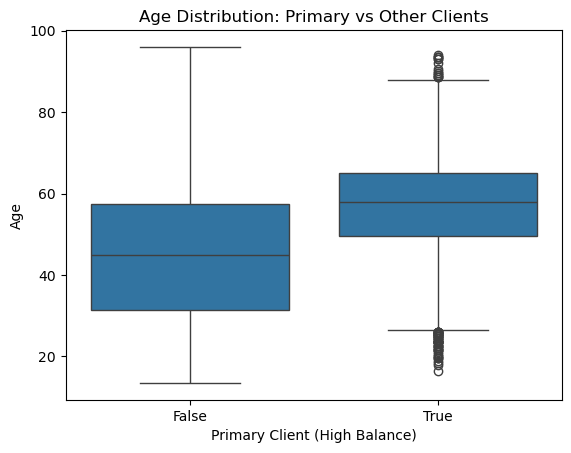

In [7]:
sns.boxplot(x="primary_client", y="clnt_age", data=df)
plt.xlabel("Primary Client (High Balance)")
plt.ylabel("Age")
plt.title("Age Distribution: Primary vs Other Clients")
plt.show()

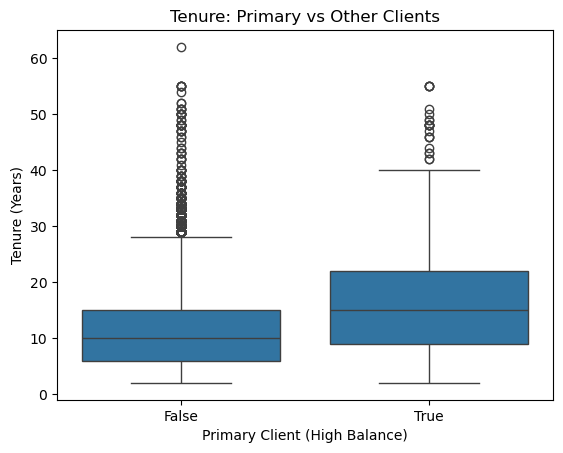

In [8]:
sns.boxplot(x="primary_client", y="clnt_tenure_yr", data=df)
plt.xlabel("Primary Client (High Balance)")
plt.ylabel("Tenure (Years)")
plt.title("Tenure: Primary vs Other Clients")
plt.show()

In [ ]:
quartiles, bins = pd.qcut(df["clnt_age"], 4, labels=["Q1", "Q2", "Q3", "Q4"], retbins=True)
df["age_quartile"] = quartiles
mean_bal_per_quartile = df.groupby("age_quartile")["bal"].mean().reset_index()

C:\Users\jorgi\AppData\Local\Temp\ipykernel_25588\1831060422.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_bal_per_quartile = df.groupby("age_quartile")["bal"].mean().reset_index()


C:\Users\jorgi\AppData\Local\Temp\ipykernel_25588\1476195605.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_with_ranges)


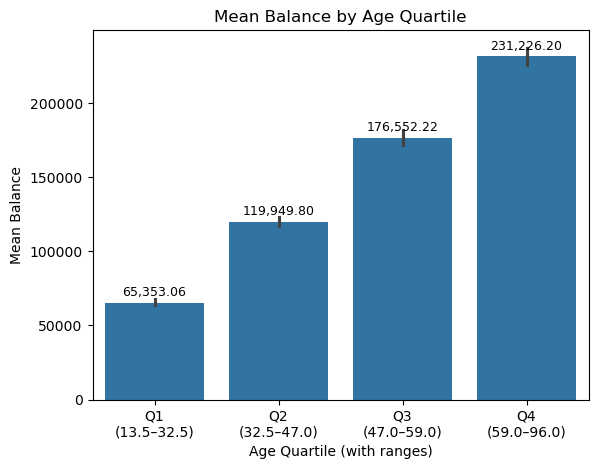

In [10]:
ax = sns.barplot(
    x="age_quartile",
    y="bal",
    data=df,
    estimator="mean",
    
)

# Replace tick labels with Q + age range
labels_with_ranges = [
    f"Q{i+1}\n({bins[i]:.1f}–{bins[i+1]:.1f})" for i in range(len(bins)-1)
]
ax.set_xticklabels(labels_with_ranges)

# Add mean balance values above bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,.2f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=9, color='black',
        xytext=(0, 3), textcoords='offset points'
    )

# Labels and title
plt.xlabel("Age Quartile (with ranges)")
plt.ylabel("Mean Balance")
plt.title("Mean Balance by Age Quartile")
plt.show()

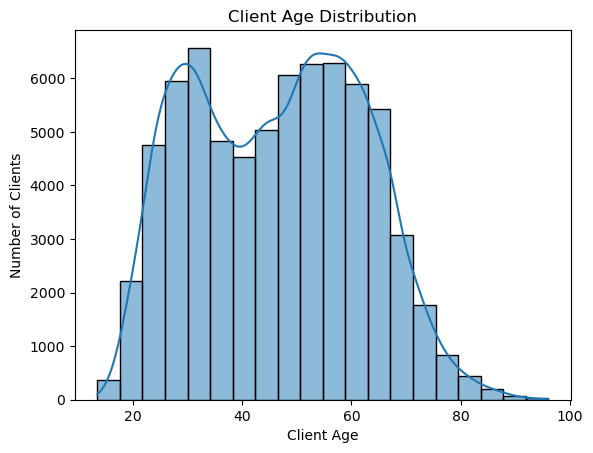

In [11]:
sns.histplot(df["clnt_age"], bins=20, kde=True)
plt.xlabel("Client Age")
plt.ylabel("Number of Clients")
plt.title("Client Age Distribution")
plt.show()

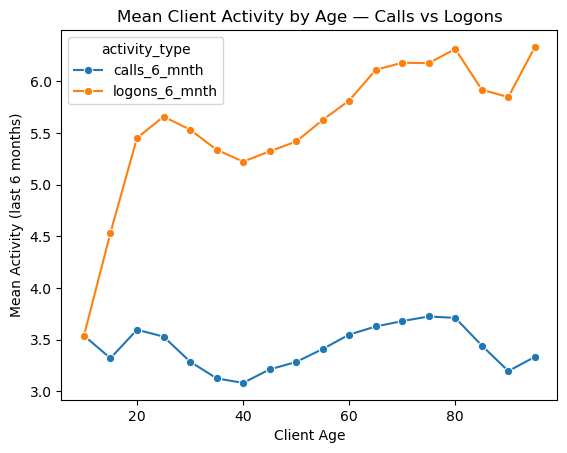

In [12]:
df["age_decade"] = (df["clnt_age"] // 5) * 5
# Group by age and calculate mean activity
activity_by_age = (
    df.groupby("age_decade")[["calls_6_mnth", "logons_6_mnth"]]
      .mean()
      .reset_index()
)

# Melt into long format for easier plotting
activity_melted = activity_by_age.melt(
    id_vars="age_decade",
    value_vars=["calls_6_mnth", "logons_6_mnth"],
    var_name="activity_type",
    value_name="mean_activity"
)

# Plot
sns.lineplot(
    x="age_decade",
    y="mean_activity",
    hue="activity_type",
    data=activity_melted,
    marker="o"
)
plt.xlabel("Client Age")
plt.ylabel("Mean Activity (last 6 months)")
plt.title("Mean Client Activity by Age — Calls vs Logons")
plt.show()

In [13]:
primary_clients = df[df["primary_client"] == True]

In [14]:
df.groupby('primary_client')[['clnt_age', 'clnt_tenure_yr']].describe().round(2)

clnt_age                                              \
                  count   mean    std   min   25%   50%   75%   max   
primary_client                                                        
False           63535.0  45.29  15.52  13.5  31.5  45.0  57.5  96.0   
True             7060.0  56.86  11.99  16.5  49.5  58.0  65.0  94.0   

               clnt_tenure_yr                                           
                        count   mean   std  min  25%   50%   75%   max  
primary_client                                                          
False                 63535.0  11.61  6.56  2.0  6.0  10.0  15.0  62.0  
True                   7060.0  16.08  8.18  2.0  9.0  15.0  22.0  55.0

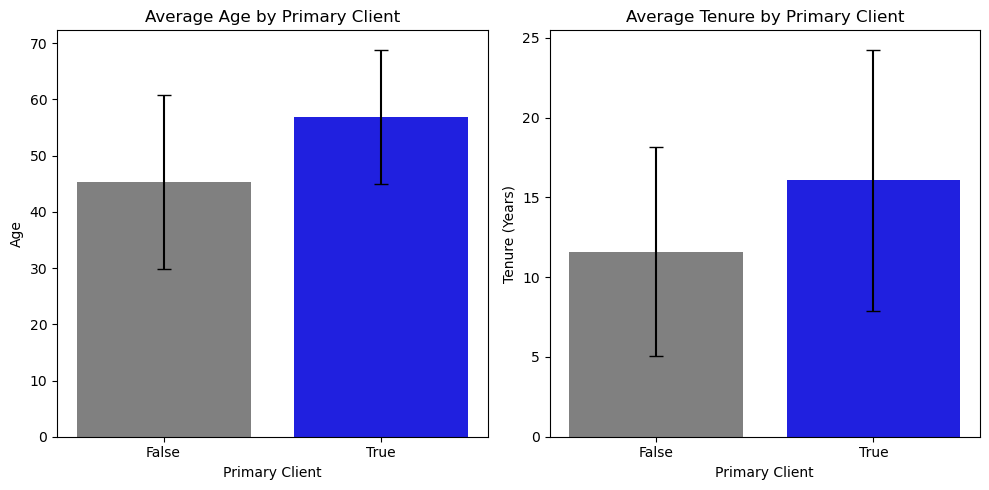

In [15]:



# Calculate summary stats
summary = df.groupby("primary_client")[["clnt_age", "clnt_tenure_yr"]].agg(['mean', 'std'])
summary.columns = ['clnt_age_mean', 'clnt_age_std', 'tenure_mean', 'tenure_std']
summary = summary.reset_index()

# ✅ Convert to bool (important for color mapping)
summary["primary_client"] = summary["primary_client"].astype(bool)

# Plot
plt.figure(figsize=(10, 5))

# Age
plt.subplot(1, 2, 1)
sns.barplot(
    data=summary,
    x="primary_client",
    y="clnt_age_mean",
    hue="primary_client",  # ✅ Required when using custom palette
    palette={True: "blue", False: "gray"},
    legend=False,
    errorbar=None  # optional: we manually use yerr
)
plt.errorbar(x=[0, 1], y=summary["clnt_age_mean"], yerr=summary["clnt_age_std"], fmt='none', c='black', capsize=5)
plt.title("Average Age by Primary Client")
plt.ylabel("Age")
plt.xlabel("Primary Client")

# Tenure
plt.subplot(1, 2, 2)
sns.barplot(
    data=summary,
    x="primary_client",
    y="tenure_mean",
    hue="primary_client",
    palette={True: "blue", False: "gray"},
    legend=False,
    errorbar=None
)
plt.errorbar(x=[0, 1], y=summary["tenure_mean"], yerr=summary["tenure_std"], fmt='none', c='black', capsize=5)
plt.title("Average Tenure by Primary Client")
plt.ylabel("Tenure (Years)")
plt.xlabel("Primary Client")

plt.tight_layout()
plt.show()



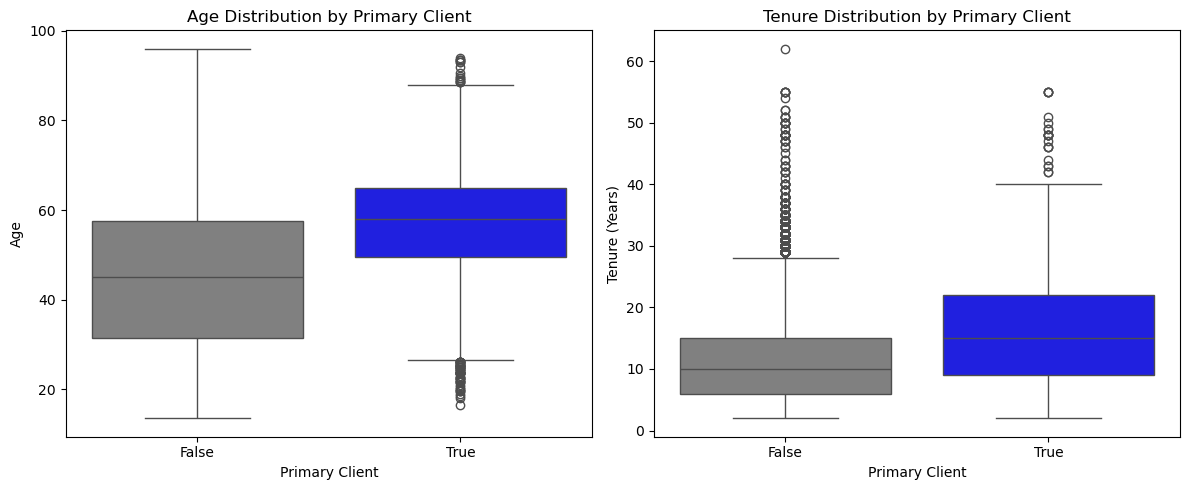

In [16]:
plt.figure(figsize=(12, 5))

# Age boxplot
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x="primary_client", y="clnt_age",hue="primary_client", palette={True: "blue", False: "gray"},legend=False)
plt.title("Age Distribution by Primary Client")
plt.xlabel("Primary Client")
plt.ylabel("Age")

# Tenure boxplot
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x="primary_client", y="clnt_tenure_yr",hue="primary_client", palette={True: "blue", False: "gray"},legend=False)
plt.title("Tenure Distribution by Primary Client")
plt.xlabel("Primary Client")
plt.ylabel("Tenure (Years)")

plt.tight_layout()
plt.show()


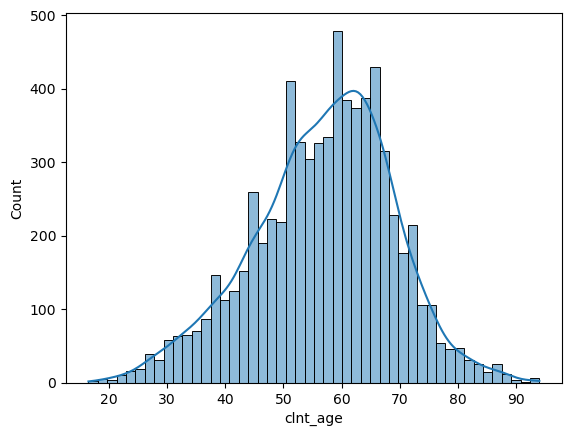

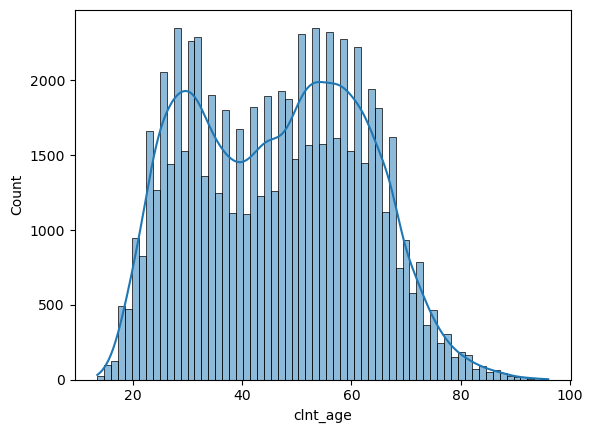

In [17]:
sns.histplot(primary_clients['clnt_age'],kde=True)
plt.show()

sns.histplot(df['clnt_age'],kde=True)

plt.show()

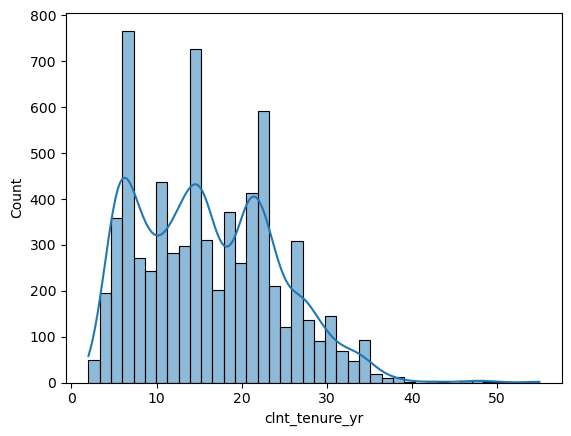

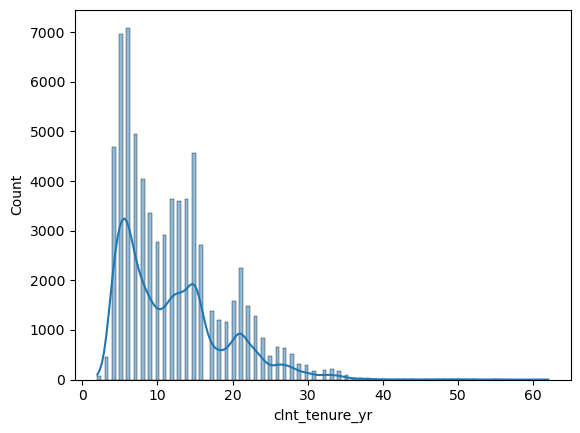

In [18]:
sns.histplot(primary_clients['clnt_tenure_yr'],kde=True)
plt.show()

sns.histplot(df['clnt_tenure_yr'],kde=True)
plt.show()

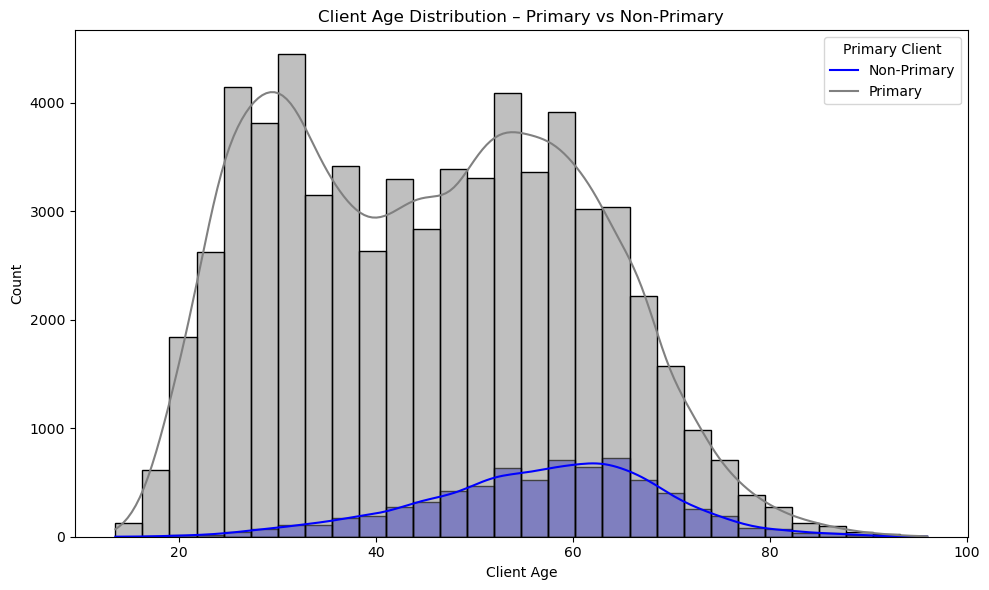

In [19]:


plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="clnt_age", hue="primary_client", kde=True, palette={True: "blue", False: "gray"}, alpha=0.5, bins=30)

plt.title("Client Age Distribution – Primary vs Non-Primary")
plt.xlabel("Client Age")
plt.ylabel("Count")
plt.legend(title="Primary Client", labels=["Non-Primary", "Primary"])
plt.tight_layout()
plt.show()


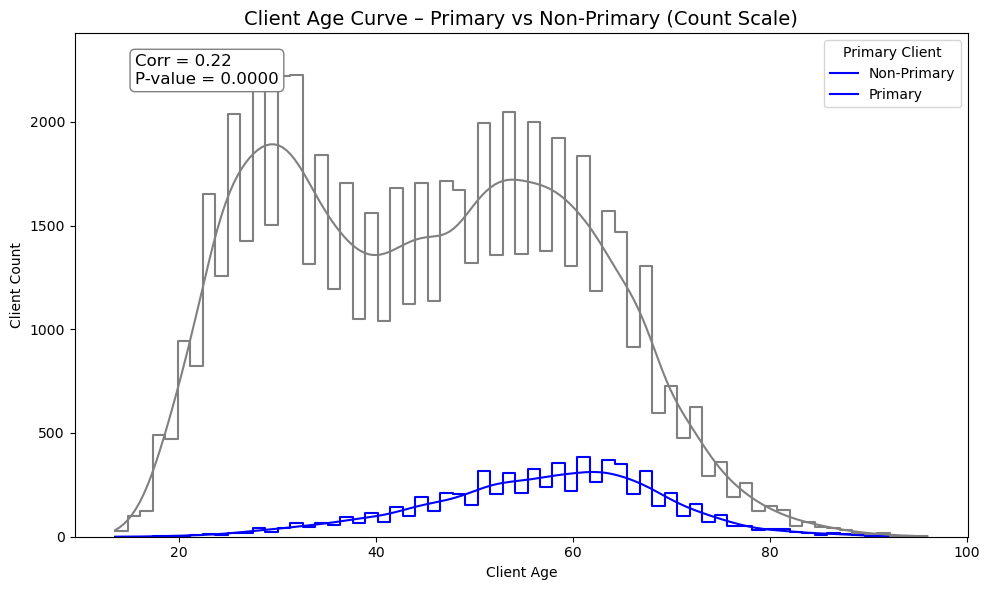

In [20]:

from scipy.stats import pointbiserialr

# Correlation calculation
corr, p = pointbiserialr(df["primary_client"].astype(int), df["clnt_age"])

# Create the figure
plt.figure(figsize=(10, 6))

# Use histplot to plot only the KDE curve on a count scale
sns.histplot(
    data=df,
    x="clnt_age",
    hue="primary_client",
    stat="count",         # y-axis is count
    kde=True,             # add KDE line
    element="step",       # don't show bars, only step-style curve
    fill=False,           # don't fill area
    common_norm=False,    # keep counts separate
    palette={True: "blue", False: "gray"}
)

# Add correlation text
plt.text(
    x=df["clnt_age"].min() + 2,
    y=plt.gca().get_ylim()[1] * 0.9,
    s=f"Corr = {corr:.2f}\nP-value = {p:.4f}",
    fontsize=12,
    color="black",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray")
)

# Labels and formatting
plt.title("Client Age Curve – Primary vs Non-Primary (Count Scale)", fontsize=14)
plt.xlabel("Client Age")
plt.ylabel("Client Count")
plt.legend(title="Primary Client", labels=["Non-Primary", "Primary"])
plt.tight_layout()
plt.show()



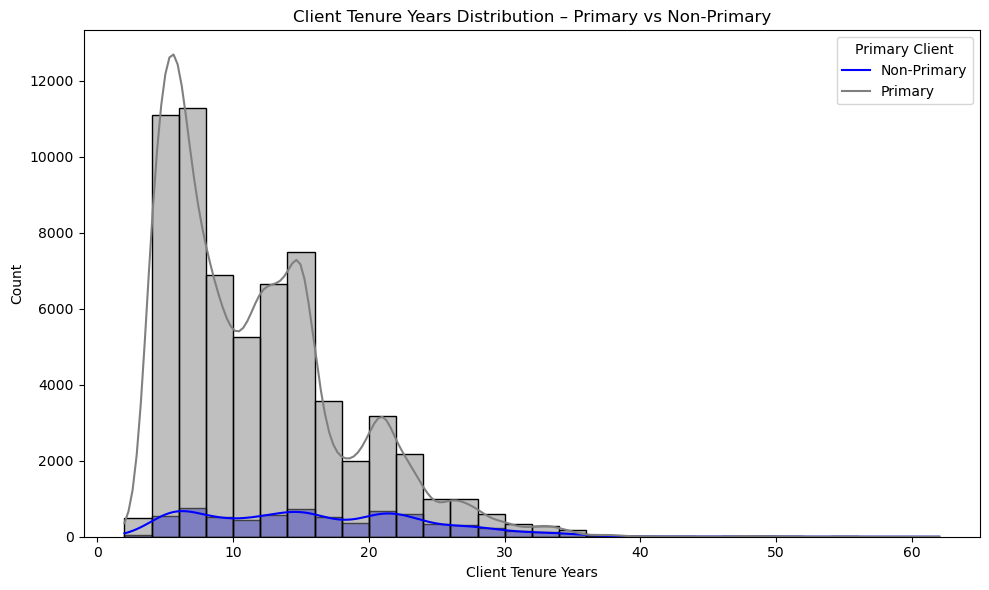

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="clnt_tenure_yr", hue="primary_client", kde=True, palette={True: "blue", False: "gray"}, alpha=0.5, bins=30)

plt.title("Client Tenure Years Distribution – Primary vs Non-Primary")
plt.xlabel("Client Tenure Years")
plt.ylabel("Count")
plt.legend(title="Primary Client", labels=["Primary", "Non-Primary"])
plt.tight_layout()
plt.show()

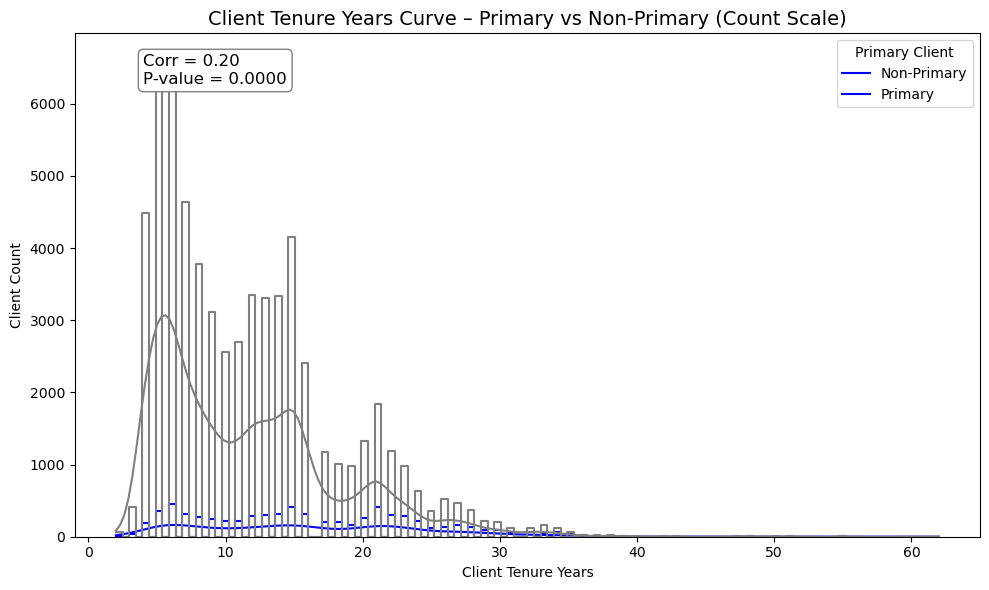

In [22]:
# Correlation calculation
corr, p = pointbiserialr(df["primary_client"].astype(int), df["clnt_tenure_yr"])

# Create the figure
plt.figure(figsize=(10, 6))

# Use histplot to plot only the KDE curve on a count scale
sns.histplot(
    data=df,
    x="clnt_tenure_yr",
    hue="primary_client",
    stat="count",         # y-axis is count
    kde=True,             # add KDE line
    element="step",       # don't show bars, only step-style curve
    fill=False,           # don't fill area
    common_norm=False,    # keep counts separate
    palette={True: "blue", False: "gray"}
)

# Add correlation text
plt.text(
    x=df["clnt_tenure_yr"].min() + 2,
    y=plt.gca().get_ylim()[1] * 0.9,
    s=f"Corr = {corr:.2f}\nP-value = {p:.4f}",
    fontsize=12,
    color="black",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray")
)

# Labels and formatting
plt.title("Client Tenure Years Curve – Primary vs Non-Primary (Count Scale)", fontsize=14)
plt.xlabel("Client Tenure Years")
plt.ylabel("Client Count")
plt.legend(title="Primary Client", labels=["Non-Primary", "Primary"])
plt.tight_layout()
plt.show()

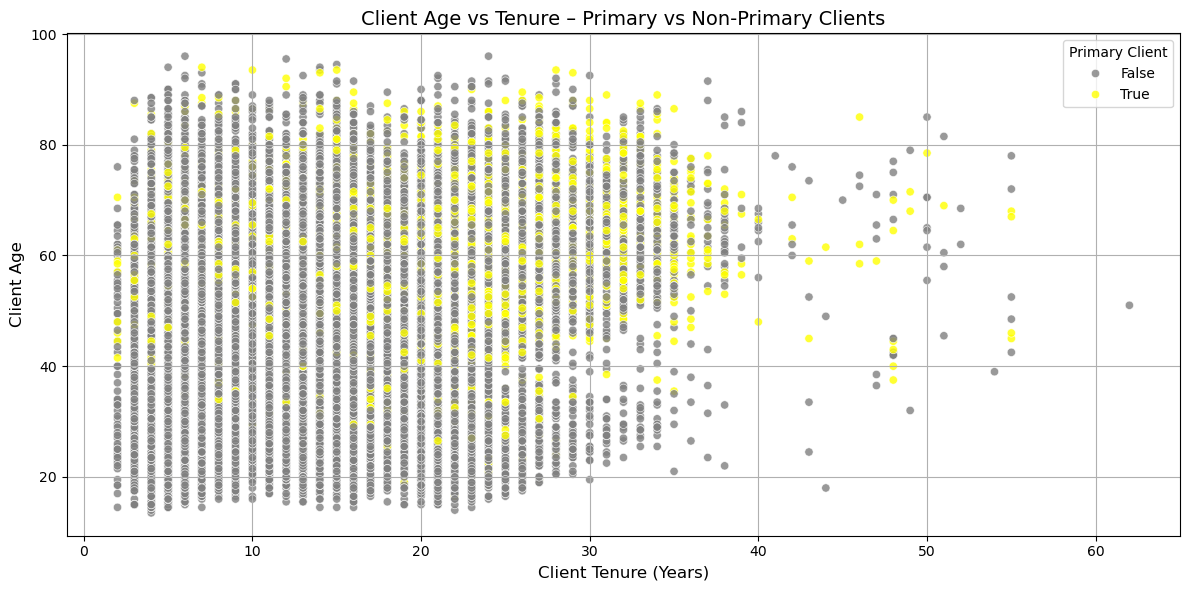

In [23]:
# Bigger figure
plt.figure(figsize=(12, 6))

# Scatterplot with hue to distinguish primary vs non-primary clients
sns.scatterplot(
    data=df,
    x="clnt_tenure_yr",
    y="clnt_age",
    hue="primary_client",       # differentiates True / False
    alpha=0.8,
    palette={True: "yellow", False: "gray"}  # optional custom colors
)

plt.title("Client Age vs Tenure – Primary vs Non-Primary Clients", fontsize=14)
plt.xlabel("Client Tenure (Years)", fontsize=12)
plt.ylabel("Client Age", fontsize=12)
plt.legend(title="Primary Client")
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\jorgi\AppData\Local\Temp\ipykernel_25588\1656523150.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, '2D Density – Age vs Tenure')

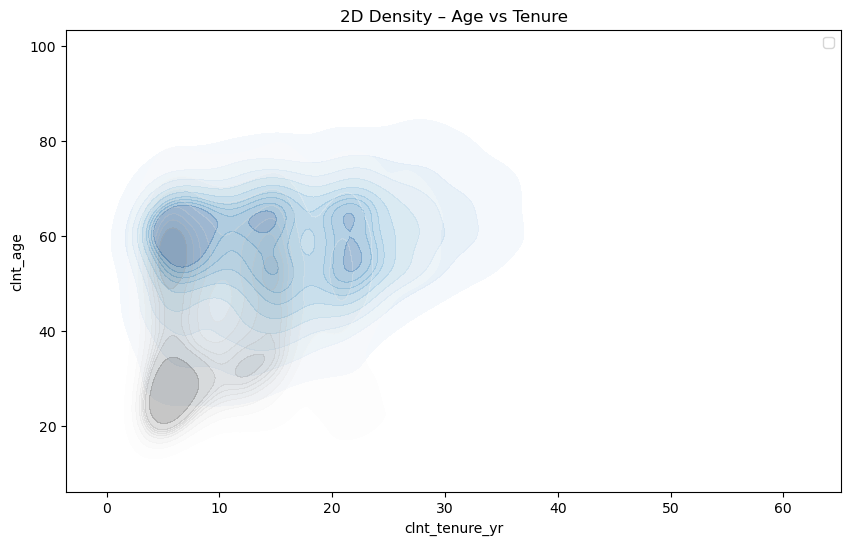

In [24]:
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df[df["primary_client"] == True],
    x="clnt_tenure_yr",
    y="clnt_age",
    fill=True,
    cmap="Blues",
    alpha=0.5,
    label="Primary"
)
sns.kdeplot(
    data=df[df["primary_client"] == False],
    x="clnt_tenure_yr",
    y="clnt_age",
    fill=True,
    cmap="Greys",
    alpha=0.3,
    label="Non-Primary"
)
plt.legend()
plt.title("2D Density – Age vs Tenure")



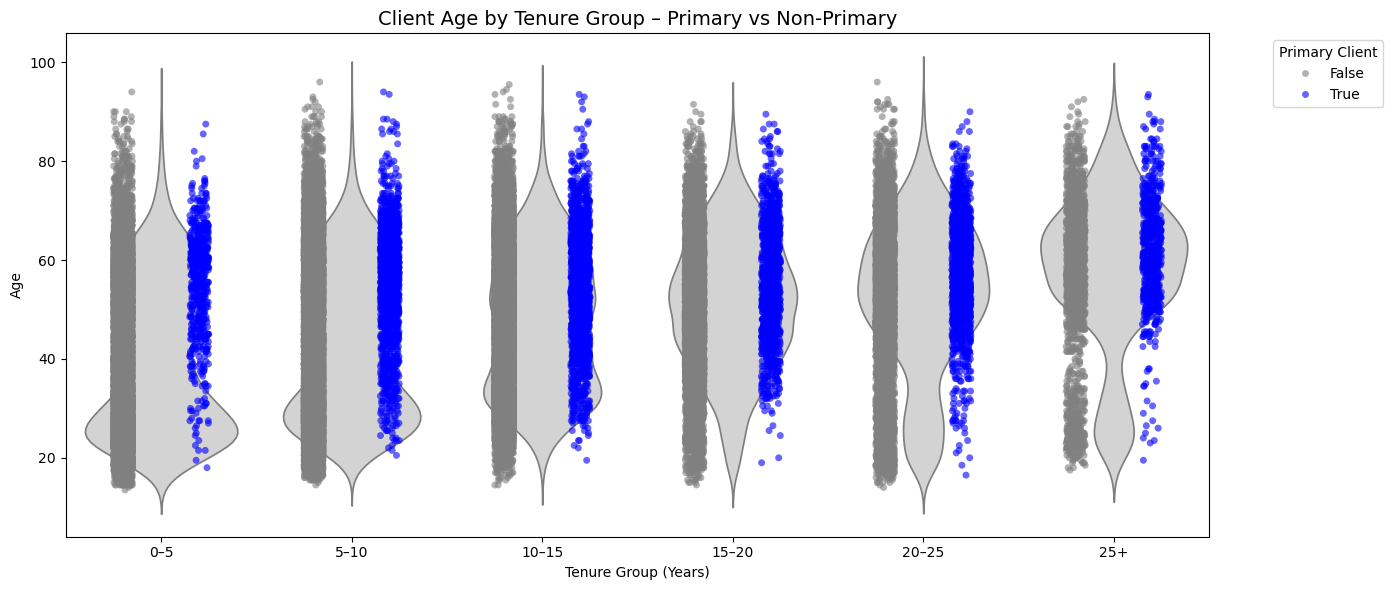

In [25]:
# Optional: bin tenure into categories
df["tenure_bin"] = pd.cut(df["clnt_tenure_yr"], bins=[0, 5, 10, 15, 20, 25, 30], labels=["0–5", "5–10", "10–15", "15–20", "20–25", "25+"])

plt.figure(figsize=(14, 6))
sns.violinplot(x="tenure_bin", y="clnt_age", data=df, inner=None, color="lightgray")
sns.stripplot(x="tenure_bin", y="clnt_age", data=df, hue="primary_client", dodge=True, alpha=0.6, palette={True: "blue", False: "gray"}, size=5)

plt.title("Client Age by Tenure Group – Primary vs Non-Primary", fontsize=14)
plt.xlabel("Tenure Group (Years)")
plt.ylabel("Age")
plt.legend(title="Primary Client", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


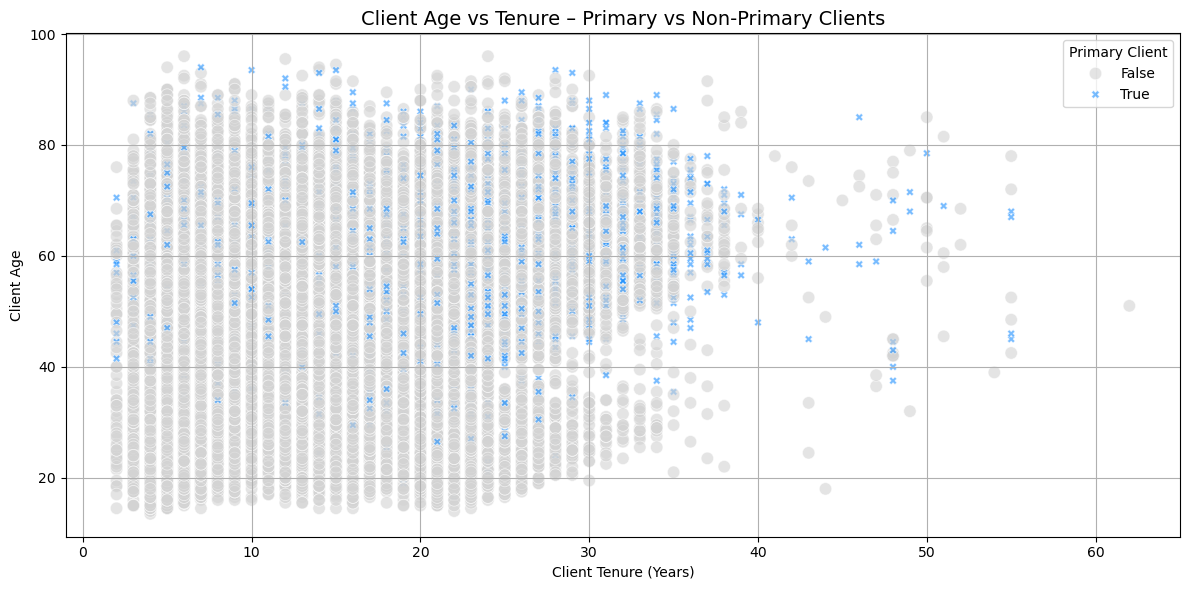

In [26]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df,
    x="clnt_tenure_yr",
    y="clnt_age",
    hue="primary_client",
    style="primary_client",         # Different shapes for each group
    palette={True: "dodgerblue", False: "lightgray"},
    size="primary_client",          # Bigger dots for primary clients
    sizes=(30, 80),
    alpha=0.6
)

plt.title("Client Age vs Tenure – Primary vs Non-Primary Clients", fontsize=14)
plt.xlabel("Client Tenure (Years)")
plt.ylabel("Client Age")
plt.legend(title="Primary Client")
plt.grid(True)
plt.tight_layout()
plt.show()


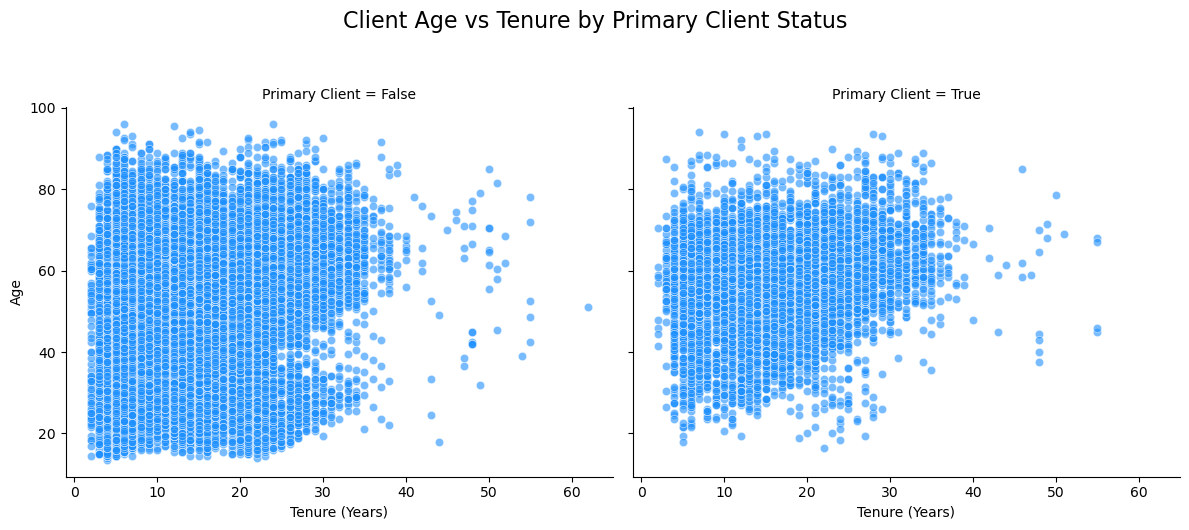

In [27]:
g = sns.FacetGrid(df, col="primary_client", height=5, aspect=1.2)
g.map_dataframe(sns.scatterplot, x="clnt_tenure_yr", y="clnt_age", alpha=0.6, color="dodgerblue")
g.set_titles("Primary Client = {col_name}")
g.set_axis_labels("Tenure (Years)", "Age")
plt.suptitle("Client Age vs Tenure by Primary Client Status", y=1.05, fontsize=16)
plt.tight_layout()
plt.show()
